# Part A — Custom ResNet for Malaria Cell Classification

**Owner:** Member A  
**Task:** Custom ResNet trained from scratch on the malaria cell-image dataset

This notebook covers the complete model workflow:

1. Access and extract the dataset
2. Inspect the dataset and class balance
3. Create stratified train/validation/test splits
4. Build the `tf.data` input pipeline
5. Define training-time augmentation
6. Implement a custom ResNet using the Keras Subclassing API
7. Train reproducible experiments with TensorBoard logging
8. Calculate accuracy, precision, recall/sensitivity, specificity, F1 and ROC-AUC
9. Compare experiments
10. Select the best experiment using validation data
11. Evaluate the selected model once on the held-out test set
12. Produce the required evaluation plots and inspect errors

> **Important:** This is a custom ResNet, not `tf.keras.applications.ResNet50`. The network is built from scratch with custom `Layer` and `Model` subclasses.

## Assignment target for this model

For the hand-implemented custom model, the assignment gives the following **target** on the held-out test set:

- **Sensitivity / recall ≥ 90%** for infected cells
- **Specificity ≥ 90%** for uninfected cells

These are evaluation targets rather than guarantees. We will not tune on the test set. Experiments use the training and validation sets; the test set is reserved for the final evaluation of the selected model.

## 1. Install dependencies

This notebook is prepared for Kaggle Notebooks and other TensorFlow environments.

Kaggle already provides the main TensorFlow/scikit-learn stack, so we do not reinstall TensorFlow. The only optional package needed by the Drive-download fallback is `gdown`.


## 2. Imports and reproducibility

In [8]:
import os
import json
import math
import random
import shutil
import zipfile
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, mixed_precision
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
)
print("TensorFlow:", tf.__version__)
SEED = 42
keras.utils.set_random_seed(SEED)
GPU_DEVICES = tf.config.list_physical_devices("GPU")
USE_GPU = bool(GPU_DEVICES)
if USE_GPU:
    mixed_precision.set_global_policy("mixed_float16")
    print("GPUs:", GPU_DEVICES)
    print("Mixed precision policy:", mixed_precision.global_policy())
else:
    mixed_precision.set_global_policy("float32")
    print("GPUs: []")
    print("Running without GPU acceleration.")
try:
    STRATEGY = tf.distribute.MirroredStrategy()
except Exception:
    STRATEGY = tf.distribute.get_strategy()
print("Number of replicas:", STRATEGY.num_replicas_in_sync)
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass


TensorFlow: 2.20.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Mixed precision policy: <DTypePolicy "mixed_float16">
INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
Number of replicas: 2


## 3. Dataset access

The notebook uses the attached Kaggle Dataset containing the `Parasitized/` and `Uninfected/` class folders.

In [9]:
from pathlib import Path
DATASET_ROOT = Path(
    "/kaggle/input/datasets/samuelabejirin/malaria-cell-images/cell_images"
)
if not DATASET_ROOT.exists():
    raise FileNotFoundError(
        f"Dataset root not found: {DATASET_ROOT}"
    )
if not (DATASET_ROOT / "Parasitized").exists():
    raise FileNotFoundError(
        f"Parasitized folder not found: {DATASET_ROOT / 'Parasitized'}"
    )
if not (DATASET_ROOT / "Uninfected").exists():
    raise FileNotFoundError(
        f"Uninfected folder not found: {DATASET_ROOT / 'Uninfected'}"
    )
print("Dataset ready!")
print("Dataset root:", DATASET_ROOT)
print(
    "Parasitized images:",
    len(list((DATASET_ROOT / "Parasitized").glob("*")))
)
print(
    "Uninfected images:",
    len(list((DATASET_ROOT / "Uninfected").glob("*")))
)


Dataset ready!
Dataset root: /kaggle/input/datasets/samuelabejirin/malaria-cell-images/cell_images
Parasitized images: 13780
Uninfected images: 13780


In [10]:
from pathlib import Path
ATTACHED_DATASET_ROOT = Path(
    "/kaggle/input/datasets/samuelabejirin/malaria-cell-images/cell_images"
)
EXTRACT_DIR = ATTACHED_DATASET_ROOT
WORK_ROOT = Path("/kaggle/working")
ZIP_PATH = WORK_ROOT / "cell_images.zip"
if not ATTACHED_DATASET_ROOT.exists():
    raise FileNotFoundError(
        f"Attached dataset not found: {ATTACHED_DATASET_ROOT}"
    )
if not (EXTRACT_DIR / "Parasitized").exists():
    raise FileNotFoundError(
        f"Parasitized folder not found: {EXTRACT_DIR / 'Parasitized'}"
    )
if not (EXTRACT_DIR / "Uninfected").exists():
    raise FileNotFoundError(
        f"Uninfected folder not found: {EXTRACT_DIR / 'Uninfected'}"
    )
print("Dataset directory:", EXTRACT_DIR)
print("Class folders:", [
    p.name for p in EXTRACT_DIR.iterdir()
    if p.is_dir()
])


Dataset directory: /kaggle/input/datasets/samuelabejirin/malaria-cell-images/cell_images
Class folders: ['Uninfected', 'Parasitized']


## 4. Inspect the dataset

The labels are defined explicitly so there is no ambiguity about which class is positive:

- `Parasitized = 1`
- `Uninfected = 0`

In [11]:
CLASS_NAMES = ["Uninfected", "Parasitized"]
CLASS_TO_INDEX = {"Uninfected": 0, "Parasitized": 1}
records = []
for class_name, label in CLASS_TO_INDEX.items():
    class_dir = EXTRACT_DIR / class_name
    image_paths = sorted(
        p for p in class_dir.rglob("*")
        if p.is_file() and p.suffix.lower() in {".png", ".jpg", ".jpeg"}
    )
    for path in image_paths:
        records.append({"path": str(path), "label": label, "class_name": class_name})
df = pd.DataFrame(records)
print("Total images:", len(df))
print("\nClass counts:")
print(df["class_name"].value_counts())
print("\nClass proportions:")
print(df["class_name"].value_counts(normalize=True))


Total images: 27558

Class counts:
class_name
Uninfected     13779
Parasitized    13779
Name: count, dtype: int64

Class proportions:
class_name
Uninfected     0.5
Parasitized    0.5
Name: proportion, dtype: float64


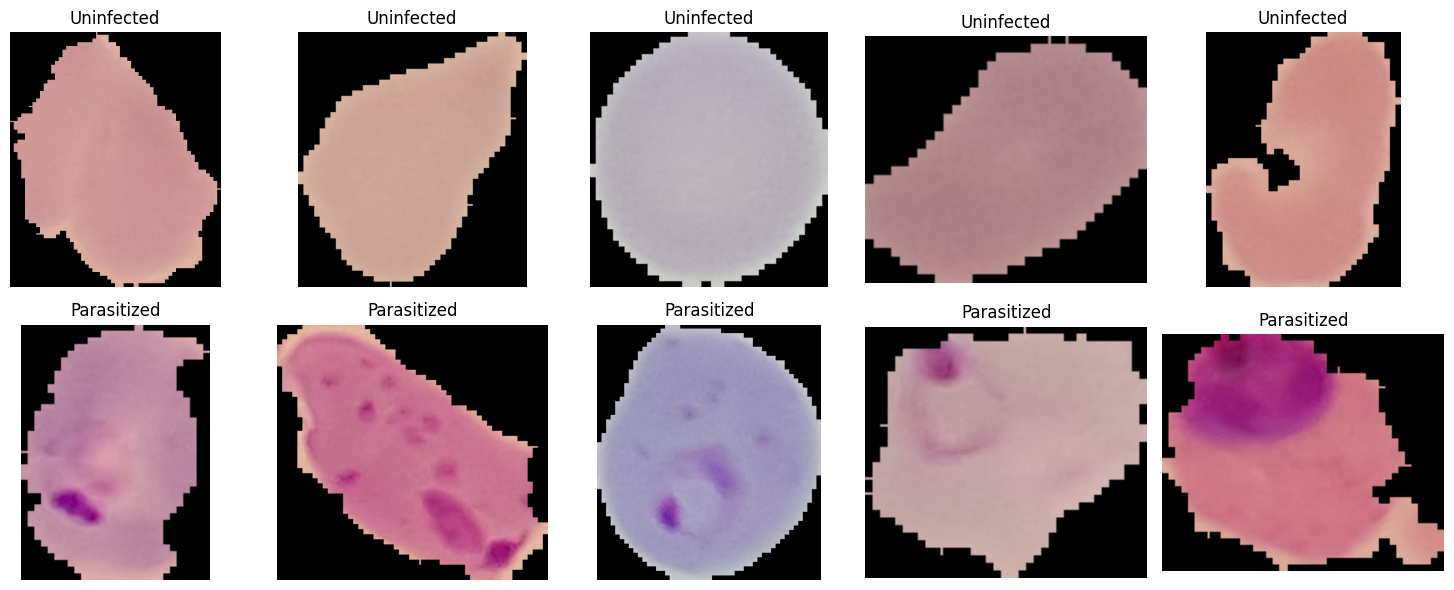

In [12]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for row, class_name in enumerate(CLASS_NAMES):
    sample_paths = df.loc[df["class_name"] == class_name, "path"].sample(5, random_state=SEED).tolist()
    for col, path in enumerate(sample_paths):
        image = plt.imread(path)
        axes[row, col].imshow(image)
        axes[row, col].set_title(class_name)
        axes[row, col].axis("off")
plt.tight_layout()
plt.show()


## 5. Stratified train / validation / test split

We use a **70 / 15 / 15** split. The split is stratified so the class balance is preserved in all three subsets.

The test set is not used for experiment decisions. It is opened only after the best configuration has been selected from validation performance.

In [13]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=SEED,
)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED,
)
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)
split_summary = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "images": [len(train_df), len(val_df), len(test_df)],
    "infected": [
        int((train_df.label == 1).sum()),
        int((val_df.label == 1).sum()),
        int((test_df.label == 1).sum()),
    ],
    "uninfected": [
        int((train_df.label == 0).sum()),
        int((val_df.label == 0).sum()),
        int((test_df.label == 0).sum()),
    ],
})
split_summary["infected_%"] = 100 * split_summary["infected"] / split_summary["images"]
print(split_summary.to_string(index=False))


     split  images  infected  uninfected  infected_%
     train   19290      9645        9645        50.0
validation    4134      2067        2067        50.0
      test    4134      2067        2067        50.0


## 6. `tf.data` input pipeline

Images are decoded as RGB, resized to `224 × 224`, converted to `float32`, and scaled to `[0, 1]`.

Augmentation is applied **only to training data**. Validation and test images are not randomly altered.

In [14]:
IMG_SIZE = (224, 224)
CHANNELS = 3
AUTOTUNE = tf.data.AUTOTUNE
def load_and_preprocess(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    label = tf.cast(label, tf.float32)
    return image, label
def make_dataset(frame, batch_size=32, shuffle=False):
    paths = frame["path"].values
    labels = frame["label"].values.astype(np.float32)
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(len(frame), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(AUTOTUNE)
    return ds


In [15]:
BATCH_SIZE = 32
train_ds = make_dataset(train_df, batch_size=BATCH_SIZE, shuffle=True)
val_ds = make_dataset(val_df, batch_size=BATCH_SIZE, shuffle=False)
test_ds = make_dataset(test_df, batch_size=BATCH_SIZE, shuffle=False)
sample_images, sample_labels = next(iter(train_ds))
print("Image batch shape:", sample_images.shape)
print("Label batch shape:", sample_labels.shape)
print("Pixel range:", float(tf.reduce_min(sample_images)), "to", float(tf.reduce_max(sample_images)))


Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Pixel range: 0.0 to 0.9153885841369629


## 7. Data augmentation

These transformations simulate harmless variation in microscope image acquisition while preserving the malaria label.

The augmentation pipeline is kept as a configurable component so experiments can compare a baseline against augmented training.

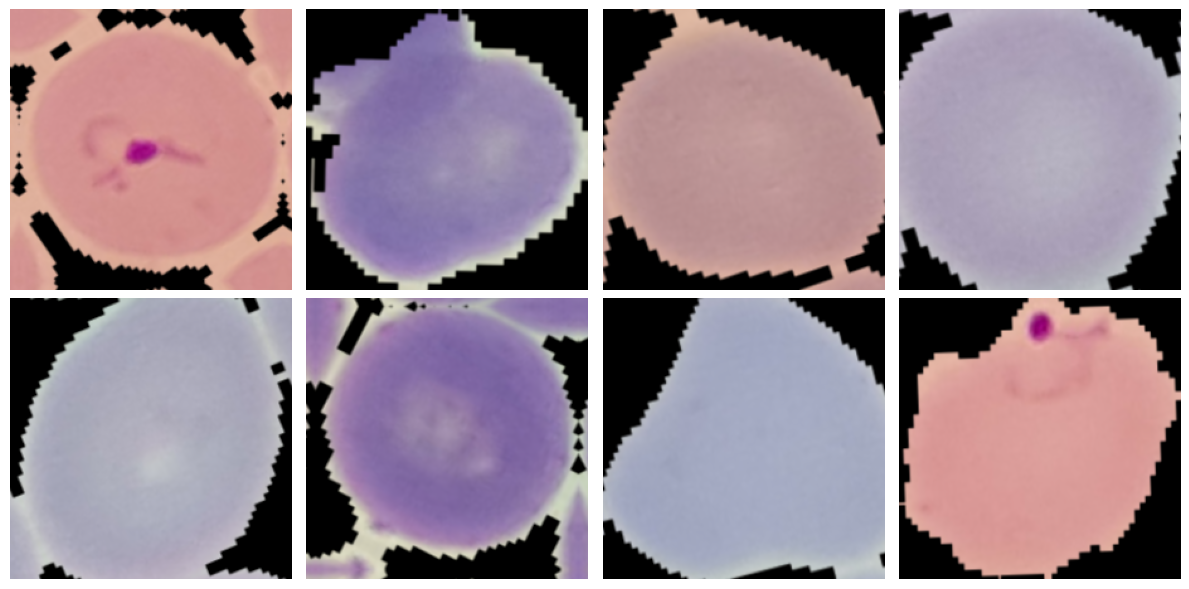

In [16]:
def make_augmentation():
    return keras.Sequential(
        [
            layers.RandomFlip("horizontal_and_vertical"),
            layers.RandomRotation(0.10),
            layers.RandomZoom(0.10),
            layers.RandomContrast(0.10),
        ],
        name="data_augmentation",
    )
augmentation_preview = make_augmentation()
augmented_images = augmentation_preview(sample_images[:8], training=True)
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax, image in zip(axes.flat, augmented_images):
    ax.imshow(tf.cast(image, tf.float32))
    ax.axis("off")
plt.tight_layout()
plt.show()


## 8. Custom residual block

This is the fundamental building block of the model.

A residual block learns a transformation `F(x)` and adds the original input through a shortcut:

`output = ReLU(F(x) + shortcut(x))`

When spatial size or channel count changes, the shortcut uses a `1 × 1` convolution with the same stride so that the tensors can be added.

In [17]:
@keras.utils.register_keras_serializable()
class ResidualBlock(layers.Layer):
    def __init__(self, filters, stride=1, dropout_rate=0.0, l2_strength=0.0, **kwargs):
        super().__init__(**kwargs)
        self.filters = filters
        self.stride = stride
        self.dropout_rate = dropout_rate
        self.l2_strength = l2_strength
        regularizer = keras.regularizers.l2(l2_strength) if l2_strength > 0 else None
        self.conv1 = layers.Conv2D(
            filters, 3, strides=stride, padding="same", use_bias=False,
            kernel_regularizer=regularizer
        )
        self.bn1 = layers.BatchNormalization()
        self.relu1 = layers.ReLU()
        self.conv2 = layers.Conv2D(
            filters, 3, strides=1, padding="same", use_bias=False,
            kernel_regularizer=regularizer
        )
        self.bn2 = layers.BatchNormalization()
        self.dropout = layers.Dropout(dropout_rate) if dropout_rate > 0 else None
        self.shortcut = None
        self.final_relu = layers.ReLU()
    def build(self, input_shape):
        input_channels = int(input_shape[-1])
        if self.stride != 1 or input_channels != self.filters:
            regularizer = keras.regularizers.l2(self.l2_strength) if self.l2_strength > 0 else None
            self.shortcut = keras.Sequential(
                [
                    layers.Conv2D(
                        self.filters, 1, strides=self.stride, padding="same", use_bias=False,
                        kernel_regularizer=regularizer
                    ),
                    layers.BatchNormalization(),
                ],
                name="projection_shortcut",
            )
        super().build(input_shape)
    def call(self, inputs, training=False):
        shortcut = inputs
        x = self.conv1(inputs)
        x = self.bn1(x, training=training)
        x = self.relu1(x)
        x = self.conv2(x)
        x = self.bn2(x, training=training)
        if self.dropout is not None:
            x = self.dropout(x, training=training)
        if self.shortcut is not None:
            shortcut = self.shortcut(inputs, training=training)
        x = layers.add([x, shortcut])
        x = self.final_relu(x)
        return x
    def get_config(self):
        config = super().get_config()
        config.update({
            "filters": self.filters,
            "stride": self.stride,
            "dropout_rate": self.dropout_rate,
            "l2_strength": self.l2_strength,
        })
        return config


## 9. Custom ResNet model

The architecture is intentionally ResNet-like but is implemented from scratch. It is suitable for Grad-CAM later because the output of the final convolutional stage is retained as `last_conv_output`.

In [18]:
@keras.utils.register_keras_serializable()
class CustomResNet(keras.Model):
    def __init__(
        self,
        num_classes=1,
        base_filters=64,
        blocks_per_stage=(2, 2, 2, 2),
        dropout_rate=0.0,
        l2_strength=0.0,
        use_augmentation=False,
        **kwargs,
    ):
        super().__init__(**kwargs)
        self.base_filters = base_filters
        self.blocks_per_stage = tuple(blocks_per_stage)
        self.dropout_rate = dropout_rate
        self.l2_strength = l2_strength
        self.use_augmentation = use_augmentation
        regularizer = keras.regularizers.l2(l2_strength) if l2_strength > 0 else None
        self.augmentation = make_augmentation() if use_augmentation else None
        self.stem_conv = layers.Conv2D(
            base_filters, 3, strides=1, padding="same", use_bias=False,
            kernel_regularizer=regularizer, name="stem_conv"
        )
        self.stem_bn = layers.BatchNormalization(name="stem_bn")
        self.stem_relu = layers.ReLU(name="stem_relu")
        filters_list = [base_filters, base_filters * 2, base_filters * 4, base_filters * 8]
        self.stages = []
        for stage_index, (filters, n_blocks) in enumerate(zip(filters_list, self.blocks_per_stage)):
            blocks = []
            for block_index in range(n_blocks):
                stride = 2 if stage_index > 0 and block_index == 0 else 1
                blocks.append(
                    ResidualBlock(
                        filters=filters,
                        stride=stride,
                        dropout_rate=dropout_rate,
                        l2_strength=l2_strength,
                        name=f"stage{stage_index + 1}_block{block_index + 1}",
                    )
                )
            self.stages.append(blocks)
        self.global_pool = layers.GlobalAveragePooling2D(name="global_average_pool")
        self.head_dropout = layers.Dropout(dropout_rate, name="head_dropout")
        self.classifier = layers.Dense(1, activation="sigmoid", name="classifier")
        self.last_conv_output = None
    def call(self, inputs, training=False):
        x = inputs
        if self.augmentation is not None:
            x = self.augmentation(x, training=training)
        x = self.stem_conv(x)
        x = self.stem_bn(x, training=training)
        x = self.stem_relu(x)
        for stage in self.stages:
            for block in stage:
                x = block(x, training=training)
        self.last_conv_output = x
        x = self.global_pool(x)
        x = self.head_dropout(x, training=training)
        return self.classifier(x)


## 10. Build and inspect the baseline architecture

In [19]:
model = CustomResNet(
    base_filters=64,
    blocks_per_stage=(2, 2, 2, 2),
    dropout_rate=0.0,
    l2_strength=0.0,
    use_augmentation=False,
    name="custom_resnet",
)
_ = model(sample_images[:2], training=False)
model.summary()


Model: "custom_resnet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ stem_conv (Conv2D)              │ (2, 224, 224, 64)      │         1,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stem_bn (BatchNormalization)    │ (2, 224, 224, 64)      │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stem_relu (ReLU)                │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage1_block1 (ResidualBlock)   │ ?                      │        74,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage1_block2 (ResidualBlock)   │ ?                      │        74,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage2_block1 (ResidualBlock)   │ ?                      │       230,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage2_block2 (ResidualBlock)   │ ?                      │       295,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage3_block1 (ResidualBlock)   │ ?                      │       920,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage3_block2 (ResidualBlock)   │ ?                      │     1,181,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage4_block1 (ResidualBlock)   │ ?                      │     3,676,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage4_block2 (ResidualBlock)   │ ?                      │     4,722,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pool             │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_dropout (Dropout)          │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier (Dense)              │ (2, 1)                 │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,178,945 (42.64 MB)

 Trainable params: 11,169,345 (42.61 MB)

 Non-trainable params: 9,600 (37.50 KB)

### Check the residual model output

In [20]:
probs = model(sample_images[:4], training=False).numpy().reshape(-1)
print("Output probabilities:", probs)
print("Output shape:", probs.shape)
print("Final convolutional feature map:", model.last_conv_output.shape)


Output probabilities: [0.524  0.518  0.5205 0.521 ]
Output shape: (4,)
Final convolutional feature map: (4, 28, 28, 512)


## 11. Metrics and evaluation helpers

The training loop can monitor Keras metrics, but the final experiment record is calculated with scikit-learn so that the definitions are explicit and the same evaluation code is used across experiments.

For this notebook:

- Positive class = `Parasitized`
- Sensitivity = recall of the positive/infected class
- Specificity = true-negative rate for `Uninfected`

In [21]:
def collect_predictions(model, dataset):
    y_true = []
    y_prob = []
    for images, labels in dataset:
        probabilities = model(images, training=False).numpy().reshape(-1)
        y_prob.extend(probabilities.tolist())
        y_true.extend(labels.numpy().reshape(-1).astype(int).tolist())
    return np.asarray(y_true), np.asarray(y_prob)
def calculate_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    specificity = tn / (tn + fp) if (tn + fp) else 0.0
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall_sensitivity": recall_score(y_true, y_pred, zero_division=0),
        "specificity": specificity,
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }
def evaluate_model(model, dataset, threshold=0.5):
    y_true, y_prob = collect_predictions(model, dataset)
    metrics = calculate_metrics(y_true, y_prob, threshold=threshold)
    return metrics, y_true, y_prob


## 12. Training callbacks, checkpoint recovery and TensorBoard logging

All run files are stored under `/kaggle/working` when running on Kaggle.

The runner uses:

- TensorBoard
- Early stopping
- ReduceLROnPlateau
- best-weight checkpointing
- Keras `BackupAndRestore` so interrupted training can resume from the latest saved training state

For Kaggle interactive notebooks, enable **Persistence → Files** (or **Variables & Files**) in the notebook settings before long training runs. Kaggle documents that files under `/kaggle/working` can be carried across interactive sessions when persistence is enabled. For a durable version/output, use **Save Version** with output saving enabled.


In [22]:
RUNNING_IN_KAGGLE = Path("/kaggle").exists()
LOG_ROOT = WORK_ROOT / "logs" / "fit"
CHECKPOINT_ROOT = WORK_ROOT / "checkpoints"
ARTIFACT_ROOT = WORK_ROOT / "artifacts"
BACKUP_ROOT = WORK_ROOT / "training_backups"
RESULTS_PATH = ARTIFACT_ROOT / "custom_resnet_experiment_results.csv"
for directory in [LOG_ROOT, CHECKPOINT_ROOT, ARTIFACT_ROOT, BACKUP_ROOT]:
    directory.mkdir(parents=True, exist_ok=True)
def recover_saved_artifacts():
    """Copy prior notebook-output artifacts from an attached Kaggle input."""
    if not RUNNING_IN_KAGGLE:
        return
    input_root = Path("/kaggle/input")
    if not input_root.exists():
        return
    patterns = [
        "custom_resnet_experiment_results.csv",
        "custom_resnet_exp_*.weights.h5",
        "custom_resnet_exp_*_history.json",
        "custom_resnet_exp_*_config.json",
    ]
    copied = 0
    for pattern in patterns:
        for source in input_root.rglob(pattern):
            if source.is_file():
                if source.name.endswith(".weights.h5"):
                    destination = CHECKPOINT_ROOT / source.name
                else:
                    destination = ARTIFACT_ROOT / source.name
                if not destination.exists():
                    shutil.copy2(source, destination)
                    copied += 1
    if copied:
        print(f"Recovered {copied} saved artifact file(s) from /kaggle/input.")
    else:
        print("No previous experiment artifacts found. Starting fresh.")
recover_saved_artifacts()
def make_callbacks(run_name, patience=2):
    run_log_dir = LOG_ROOT / run_name
    checkpoint_path = CHECKPOINT_ROOT / f"{run_name}.weights.h5"
    backup_dir = BACKUP_ROOT / run_name
    backup_dir.mkdir(parents=True, exist_ok=True)
    return [
        keras.callbacks.BackupAndRestore(
            backup_dir=str(backup_dir)
        ),
        keras.callbacks.TensorBoard(
            log_dir=str(run_log_dir),
            histogram_freq=0,
            write_graph=True,
            update_freq="epoch",
        ),
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=patience,
            restore_best_weights=True,
            verbose=1,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=max(1, patience // 2),
            min_lr=1e-7,
            verbose=1,
        ),
        keras.callbacks.ModelCheckpoint(
            filepath=str(checkpoint_path),
            monitor="val_loss",
            save_best_only=True,
            save_weights_only=True,
            verbose=1,
        ),
    ]


Recovered 20 saved artifact file(s) from /kaggle/input.


## 13. Experiment runner

Each experiment is defined by a configuration dictionary. The runner creates a fresh model, compiles it, trains it, evaluates it on the **validation set**, and writes the final validation metrics into TensorBoard.

The test set is intentionally not touched here.

In [23]:
def build_resnet_from_config(config):
    return CustomResNet(
        base_filters=config.get("base_filters", 64),
        blocks_per_stage=tuple(config.get("blocks_per_stage", (2, 2, 2, 2))),
        dropout_rate=config.get("dropout_rate", 0.0),
        l2_strength=config.get("l2_strength", 0.0),
        use_augmentation=config.get("use_augmentation", False),
        name=config["name"],
    )
def compile_model(model, config):
    optimizer_name = config.get("optimizer", "adam").lower()
    learning_rate = config.get("learning_rate", 1e-3)
    if optimizer_name == "adam":
        optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    elif optimizer_name == "adamw":
        optimizer = keras.optimizers.AdamW(
            learning_rate=learning_rate,
            weight_decay=config.get("weight_decay", 1e-4),
        )
    elif optimizer_name == "rmsprop":
        optimizer = keras.optimizers.RMSprop(learning_rate=learning_rate)
    elif optimizer_name == "sgd":
        optimizer = keras.optimizers.SGD(
            learning_rate=learning_rate,
            momentum=config.get("momentum", 0.9),
        )
    else:
        raise ValueError(f"Unknown optimizer: {optimizer_name}")
    model.compile(
        optimizer=optimizer,
        loss=keras.losses.BinaryCrossentropy(),
        metrics=[
            keras.metrics.BinaryAccuracy(name="accuracy"),
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
            keras.metrics.AUC(name="roc_auc"),
        ],
    )
def log_final_metrics_to_tensorboard(run_name, metrics, epoch):
    writer = tf.summary.create_file_writer(str(LOG_ROOT / run_name))
    with writer.as_default():
        for key, value in metrics.items():
            if isinstance(value, (int, float, np.integer, np.floating)):
                tf.summary.scalar(f"final_validation/{key}", value, step=epoch)
        writer.flush()
def save_experiment_result(result):
    if RESULTS_PATH.exists():
        existing = pd.read_csv(RESULTS_PATH)
        existing = existing[existing["name"] != result["name"]]
        combined = pd.concat([existing, pd.DataFrame([result])], ignore_index=True)
    else:
        combined = pd.DataFrame([result])
    combined.to_csv(RESULTS_PATH, index=False)
    config_path = ARTIFACT_ROOT / f"{result['name']}_config.json"
    with open(config_path, "w") as f:
        json.dump(
            result,
            f,
            indent=2,
            default=lambda x: list(x) if isinstance(x, tuple) else str(x),
        )
def run_experiment(config):
    run_name = config["name"]
    batch_size = config.get("batch_size", 32)
    epochs = config.get("epochs", 8)
    print("=" * 80)
    print(f"Running: {run_name}")
    print("=" * 80)
    print(json.dumps(
        config,
        indent=2,
        default=lambda x: list(x) if isinstance(x, tuple) else str(x),
    ))
    keras.backend.clear_session()
    keras.utils.set_random_seed(SEED)
    local_train_ds = make_dataset(train_df, batch_size=batch_size, shuffle=True)
    local_val_ds = make_dataset(val_df, batch_size=batch_size, shuffle=False)
    with STRATEGY.scope():
        model = build_resnet_from_config(config)
        first_batch = next(iter(local_train_ds))[0][:2]
        _ = model(first_batch, training=False)
        compile_model(model, config)
    callbacks = make_callbacks(
        run_name,
        patience=config.get("early_stopping_patience", 2),
    )
    history = model.fit(
        local_train_ds,
        validation_data=local_val_ds,
        epochs=epochs,
        callbacks=callbacks,
        verbose=1,
    )
    checkpoint_path = CHECKPOINT_ROOT / f"{run_name}.weights.h5"
    if checkpoint_path.exists():
        model.load_weights(checkpoint_path)
    val_metrics, _, _ = evaluate_model(
        model,
        local_val_ds,
        threshold=config.get("threshold", 0.5),
    )
    best_epoch = int(np.argmin(history.history["val_loss"]) + 1)
    result = dict(config)
    result.update({f"val_{k}": v for k, v in val_metrics.items()})
    result["best_epoch"] = best_epoch
    result["trained_epochs"] = len(history.history["loss"])
    log_final_metrics_to_tensorboard(run_name, val_metrics, best_epoch)
    history_path = ARTIFACT_ROOT / f"{run_name}_history.json"
    with open(history_path, "w") as f:
        json.dump(
            {
                key: [float(v) for v in values]
                for key, values in history.history.items()
            },
            f,
            indent=2,
        )
    save_experiment_result(result)
    print(f"Saved checkpoint, history and results for {run_name}.")
    return model, history, result


## 14. Experiment 01 — baseline

Start with a plain custom ResNet. This establishes the reference point before augmentation, regularization, or architectural changes.

In [24]:
BASELINE_CONFIG = {
    "name": "custom_resnet_exp_01_baseline",
    "base_filters": 64,
    "blocks_per_stage": (2, 2, 2, 2),
    "learning_rate": 1e-3,
    "optimizer": "adam",
    "batch_size": 32,
    "epochs": 8,
    "use_augmentation": False,
    "dropout_rate": 0.0,
    "l2_strength": 0.0,
    "early_stopping_patience": 2,
}
print("Experiment 1 configuration loaded. The resumable runner below handles training.")


Experiment 1 configuration loaded. The resumable runner below handles training.


## 15. Seven experiment configurations

The seven experiments isolate augmentation, learning rate, dropout, L2 regularization, optimizer choice, and network depth. Each run uses the same stratified validation protocol.

In [25]:
EXPERIMENTS = [
    {
        "name": "custom_resnet_exp_01_baseline",
        "base_filters": 64,
        "blocks_per_stage": (2, 2, 2, 2),
        "learning_rate": 1e-3,
        "optimizer": "adam",
        "batch_size": 32,
        "epochs": 8,
        "use_augmentation": False,
        "dropout_rate": 0.0,
        "l2_strength": 0.0,
        "early_stopping_patience": 2,
    },
    {
        "name": "custom_resnet_exp_02_augmentation",
        "base_filters": 64,
        "blocks_per_stage": (2, 2, 2, 2),
        "learning_rate": 1e-3,
        "optimizer": "adam",
        "batch_size": 32,
        "epochs": 8,
        "use_augmentation": True,
        "dropout_rate": 0.0,
        "l2_strength": 0.0,
        "early_stopping_patience": 2,
    },
    {
        "name": "custom_resnet_exp_03_lr_1e-4",
        "base_filters": 64,
        "blocks_per_stage": (2, 2, 2, 2),
        "learning_rate": 1e-4,
        "optimizer": "adam",
        "batch_size": 32,
        "epochs": 8,
        "use_augmentation": True,
        "dropout_rate": 0.0,
        "l2_strength": 0.0,
        "early_stopping_patience": 2,
    },
    {
        "name": "custom_resnet_exp_04_dropout_03",
        "base_filters": 64,
        "blocks_per_stage": (2, 2, 2, 2),
        "learning_rate": 1e-4,
        "optimizer": "adam",
        "batch_size": 32,
        "epochs": 8,
        "use_augmentation": True,
        "dropout_rate": 0.30,
        "l2_strength": 0.0,
        "early_stopping_patience": 2,
    },
    {
        "name": "custom_resnet_exp_05_l2_1e-4",
        "base_filters": 64,
        "blocks_per_stage": (2, 2, 2, 2),
        "learning_rate": 1e-4,
        "optimizer": "adam",
        "batch_size": 32,
        "epochs": 8,
        "use_augmentation": True,
        "dropout_rate": 0.30,
        "l2_strength": 1e-4,
        "early_stopping_patience": 2,
    },
    {
        "name": "custom_resnet_exp_06_adamw",
        "base_filters": 64,
        "blocks_per_stage": (2, 2, 2, 2),
        "learning_rate": 1e-4,
        "optimizer": "adamw",
        "weight_decay": 1e-4,
        "batch_size": 32,
        "epochs": 8,
        "use_augmentation": True,
        "dropout_rate": 0.30,
        "l2_strength": 0.0,
        "early_stopping_patience": 2,
    },
    {
        "name": "custom_resnet_exp_07_deeper",
        "base_filters": 64,
        "blocks_per_stage": (2, 2, 3, 3),
        "learning_rate": 1e-4,
        "optimizer": "adamw",
        "weight_decay": 1e-4,
        "batch_size": 32,
        "epochs": 8,
        "use_augmentation": True,
        "dropout_rate": 0.30,
        "l2_strength": 0.0,
        "early_stopping_patience": 2,
    },
]
experiment_table = pd.DataFrame(EXPERIMENTS)
experiment_table[[
    "name", "learning_rate", "optimizer", "batch_size",
    "epochs", "use_augmentation", "dropout_rate",
    "l2_strength", "blocks_per_stage"
]]


,name,learning_rate,optimizer,batch_size,epochs,use_augmentation,dropout_rate,l2_strength,blocks_per_stage
0,custom_resnet_exp_01_baseline,0.0010,adam,32,8,False,0.0,0.0000,"(2, 2, 2, 2)"
1,custom_resnet_exp_02_augmentation,0.0010,adam,32,8,True,0.0,0.0000,"(2, 2, 2, 2)"
2,custom_resnet_exp_03_lr_1e-4,0.0001,adam,32,8,True,0.0,0.0000,"(2, 2, 2, 2)"
3,custom_resnet_exp_04_dropout_03,0.0001,adam,32,8,True,0.3,0.0000,"(2, 2, 2, 2)"
4,custom_resnet_exp_05_l2_1e-4,0.0001,adam,32,8,True,0.3,0.0001,"(2, 2, 2, 2)"
5,custom_resnet_exp_06_adamw,0.0001,adamw,32,8,True,0.3,0.0000,"(2, 2, 2, 2)"
6,custom_resnet_exp_07_deeper,0.0001,adamw,32,8,True,0.3,0.0000,"(2, 2, 3, 3)"


## 16. Run experiments

The runner below is resumable across Kaggle sessions.

- 7 meaningful experiments.
- Maximum 8 epochs per experiment.
- Batch size 32 to avoid the T4 OOM seen with batch 64.
- Completed experiments are skipped when both their results and checkpoint are present.
- Results, histories, configurations and checkpoints are saved immediately after each completed experiment.
- If a session ends during an experiment, only that incomplete experiment needs to be rerun.

For long runs, save a Kaggle Notebook Version with output files after a completed batch. Kaggle supports creating a dataset from notebook output files and attaching those outputs to a later notebook. This is the recovery path used by the notebook.


In [26]:
def load_saved_results():
    if RESULTS_PATH.exists():
        return pd.read_csv(RESULTS_PATH)
    return pd.DataFrame()
def checkpoint_exists(run_name):
    return (CHECKPOINT_ROOT / f"{run_name}.weights.h5").exists()
def run_all_resumable():
    results_df = load_saved_results()
    for config in EXPERIMENTS:
        run_name = config["name"]
        if (
            run_name in set(results_df.get("name", pd.Series(dtype=str)))
            and checkpoint_exists(run_name)
        ):
            print(f"SKIP {run_name}: completed results and checkpoint already exist.")
            continue
        print(f"START {run_name}")
        model, history, result = run_experiment(config)
        results_df = load_saved_results()
        print(f"DONE {run_name}")
        print(
            results_df[[
                "name",
                "val_accuracy",
                "val_precision",
                "val_recall_sensitivity",
                "val_specificity",
                "val_f1",
                "val_roc_auc",
                "best_epoch",
            ]].sort_values("name").to_string(index=False)
        )
    return load_saved_results()
experiment_results_df = run_all_resumable()
display(experiment_results_df)


SKIP custom_resnet_exp_01_baseline: completed results and checkpoint already exist.
SKIP custom_resnet_exp_02_augmentation: completed results and checkpoint already exist.
SKIP custom_resnet_exp_03_lr_1e-4: completed results and checkpoint already exist.
SKIP custom_resnet_exp_04_dropout_03: completed results and checkpoint already exist.
SKIP custom_resnet_exp_05_l2_1e-4: completed results and checkpoint already exist.
SKIP custom_resnet_exp_06_adamw: completed results and checkpoint already exist.
START custom_resnet_exp_07_deeper
Running: custom_resnet_exp_07_deeper
{
  "name": "custom_resnet_exp_07_deeper",
  "base_filters": 64,
  "blocks_per_stage": [
    2,
    2,
    3,
    3
  ],
  "learning_rate": 0.0001,
  "optimizer": "adamw",
  "weight_decay": 0.0001,
  "batch_size": 32,
  "epochs": 8,
  "use_augmentation": true,
  "dropout_rate": 0.3,
  "l2_strength": 0.0,
  "early_stopping_patience": 2
}
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast

E0000 00:00:1790901307.073793      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/custom_resnet_exp_07_deeper_1/stage1_block1_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


603/603 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8340 - loss: 0.3838 - precision: 0.8535 - recall: 0.8109 - roc_auc: 0.8960
Epoch 1: val_loss improved from None to 0.18060, saving model to /kaggle/working/checkpoints/custom_resnet_exp_07_deeper.weights.h5

Epoch 1: finished saving model to /kaggle/working/checkpoints/custom_resnet_exp_07_deeper.weights.h5
603/603 ━━━━━━━━━━━━━━━━━━━━ 1046s 2s/step - accuracy: 0.9117 - loss: 0.2393 - precision: 0.9360 - recall: 0.8838 - roc_auc: 0.9631 - val_accuracy: 0.9548 - val_loss: 0.1806 - val_precision: 0.9608 - val_recall: 0.9482 - val_roc_auc: 0.9804 - learning_rate: 1.0000e-04
Epoch 2/8
603/603 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9462 - loss: 0.1731 - precision: 0.9709 - recall: 0.9212 - roc_auc: 0.9771
Epoch 2: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.

Epoch 2: val_loss did not improve from 0.18060
603/603 ━━━━━━━━━━━━━━━━━━━━ 1028s 2s/step - accuracy: 0.9485 - loss: 0.1668 - precision: 0.9709 - recall

,name,base_filters,blocks_per_stage,learning_rate,optimizer,batch_size,epochs,use_augmentation,dropout_rate,l2_strength,...,val_specificity,val_f1,val_roc_auc,val_tn,val_fp,val_fn,val_tp,best_epoch,trained_epochs,weight_decay
0,custom_resnet_exp_01_baseline,64,"(2, 2, 2, 2)",0.0010,adam,32,8,False,0.0,0.0000,...,0.984519,0.940167,0.982081,2035,32,205,1862,2,4,NaN
1,custom_resnet_exp_02_augmentation,64,"(2, 2, 2, 2)",0.0010,adam,32,8,True,0.0,0.0000,...,0.964683,0.962927,0.990412,1994,73,80,1987,8,8,NaN
2,custom_resnet_exp_03_lr_1e-4,64,"(2, 2, 2, 2)",0.0001,adam,32,8,True,0.0,0.0000,...,0.975810,0.956886,0.991395,2017,50,125,1942,4,6,NaN
3,custom_resnet_exp_04_dropout_03,64,"(2, 2, 2, 2)",0.0001,adam,32,8,True,0.3,0.0000,...,0.966134,0.962118,0.991353,1997,70,86,1981,5,7,NaN
4,custom_resnet_exp_05_l2_1e-4,64,"(2, 2, 2, 2)",0.0001,adam,32,8,True,0.3,0.0001,...,0.979681,0.955165,0.989757,2025,42,139,1928,8,8,NaN
5,custom_resnet_exp_06_adamw,64,"(2, 2, 2, 2)",0.0001,adamw,32,8,True,0.3,0.0000,...,0.966134,0.962118,0.991353,1997,70,86,1981,5,7,0.0001
6,custom_resnet_exp_07_deeper,64,"(2, 2, 3, 3)",0.0001,adamw,32,8,True,0.3,0.0000,...,0.982100,0.960474,0.991818,2030,37,123,1944,7,8,0.0001


## 17. Plot training and validation curves

In [28]:
trained_histories = {}
for history_file in ARTIFACT_ROOT.glob("custom_resnet_exp_*_history.json"):
    run_name = history_file.name.replace("_history.json", "")
    with open(history_file, "r") as f:
        trained_histories[run_name] = json.load(f)
print("Loaded histories:")
for run_name in sorted(trained_histories):
    print(run_name)


Loaded histories:
custom_resnet_exp_01_baseline
custom_resnet_exp_02_augmentation
custom_resnet_exp_03_lr_1e-4
custom_resnet_exp_04_dropout_03
custom_resnet_exp_05_l2_1e-4
custom_resnet_exp_06_adamw
custom_resnet_exp_07_deeper


In [31]:
def plot_training_history(history, title_prefix="Custom ResNet"):
    if isinstance(history, dict):
        history_dict = history
    else:
        history_dict = history.history
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(history_dict["accuracy"], label="Training accuracy")
    ax.plot(history_dict["val_accuracy"], label="Validation accuracy")
    ax.set_title(f"{title_prefix} Accuracy")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.legend()
    plt.show()
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(history_dict["loss"], label="Training loss")
    ax.plot(history_dict["val_loss"], label="Validation loss")
    ax.set_title(f"{title_prefix} Loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()
    plt.show()


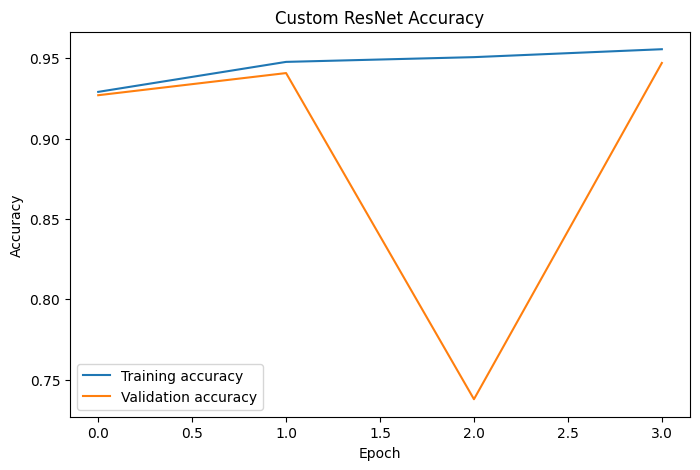

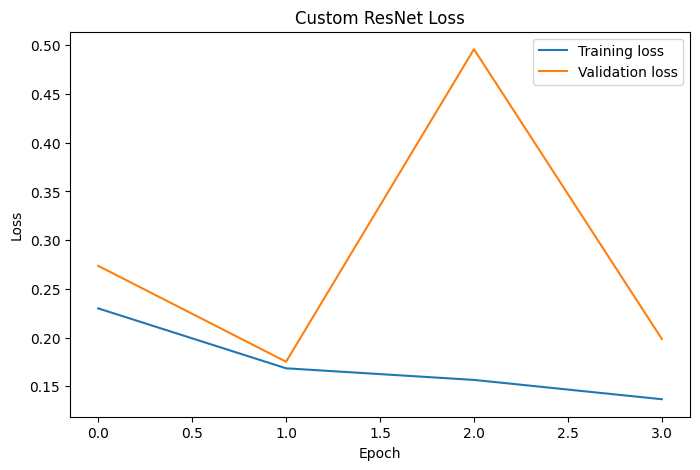

In [32]:
plot_training_history(
    trained_histories["custom_resnet_exp_01_baseline"]
)


## 18. Compare experiment results

In [33]:
def load_results_if_available():
    if RESULTS_PATH.exists():
        return pd.read_csv(RESULTS_PATH)
    raise FileNotFoundError("No saved experiment results found yet. Run the resumable experiment cell first.")
def show_experiment_comparison(results_df):
    metric_columns = [
        "val_accuracy",
        "val_precision",
        "val_recall_sensitivity",
        "val_specificity",
        "val_f1",
        "val_roc_auc",
    ]
    available = [c for c in metric_columns if c in results_df.columns]
    return results_df[["name"] + available].sort_values("val_f1", ascending=False)
results_df = load_results_if_available()
display(show_experiment_comparison(results_df))


,name,val_accuracy,val_precision,val_recall_sensitivity,val_specificity,val_f1,val_roc_auc
1,custom_resnet_exp_02_augmentation,0.962990,0.964563,0.961297,0.964683,0.962927,0.990412
5,custom_resnet_exp_06_adamw,0.962264,0.965870,0.958394,0.966134,0.962118,0.991353
3,custom_resnet_exp_04_dropout_03,0.962264,0.965870,0.958394,0.966134,0.962118,0.991353
6,custom_resnet_exp_07_deeper,0.961297,0.981323,0.940493,0.982100,0.960474,0.991818
2,custom_resnet_exp_03_lr_1e-4,0.957668,0.974900,0.939526,0.975810,0.956886,0.991395
4,custom_resnet_exp_05_l2_1e-4,0.956217,0.978680,0.932753,0.979681,0.955165,0.989757
0,custom_resnet_exp_01_baseline,0.942671,0.983105,0.900822,0.984519,0.940167,0.982081


## 19. Select the final experiment using validation data

Do not select the final model using the test set. The test set should remain unseen until this point.

A sensible selection rule is to consider the required clinical metrics together rather than choosing the highest raw accuracy automatically. The code below first identifies configurations meeting both custom-model target metrics on validation data, then sorts those by F1 and ROC-AUC. If none meets both targets, it still returns the strongest validation candidate for discussion.

In [34]:
def select_best_experiment(results_df):
    candidates = results_df.copy()
    target_mask = (
        (candidates["val_recall_sensitivity"] >= 0.90) &
        (candidates["val_specificity"] >= 0.90)
    )
    target_candidates = candidates[target_mask]
    if len(target_candidates) > 0:
        selected = target_candidates.sort_values(
            ["val_f1", "val_roc_auc", "val_accuracy"],
            ascending=False,
        ).iloc[0]
        selection_reason = "Met both 90% validation sensitivity and specificity targets; selected using F1, ROC-AUC and accuracy."
    else:
        selected = candidates.sort_values(
            ["val_f1", "val_roc_auc", "val_accuracy"],
            ascending=False,
        ).iloc[0]
        selection_reason = "No run met both validation targets; selected the strongest validation candidate using F1, ROC-AUC and accuracy."
    return selected, selection_reason
selected_row, selection_reason = select_best_experiment(results_df)
print("Selected:", selected_row["name"])
print(selection_reason)


Selected: custom_resnet_exp_02_augmentation
Met both 90% validation sensitivity and specificity targets; selected using F1, ROC-AUC and accuracy.


## 20. Final held-out test evaluation

After the experiment has been selected, reload its checkpoint and evaluate it exactly once on the test set.

This is the number that should eventually be used for the final model's held-out performance.

In [35]:
def load_model_from_config(config):
    keras.backend.clear_session()
    keras.utils.set_random_seed(SEED)
    with STRATEGY.scope():
        model = build_resnet_from_config(config)
        dummy = tf.zeros(
            (1, IMG_SIZE[0], IMG_SIZE[1], CHANNELS),
            dtype=tf.float32,
        )
        _ = model(dummy, training=False)
        compile_model(model, config)
    checkpoint_path = CHECKPOINT_ROOT / f"{config['name']}.weights.h5"
    if not checkpoint_path.exists():
        raise FileNotFoundError(f"Checkpoint not found: {checkpoint_path}")
    model.load_weights(checkpoint_path)
    return model
def final_test_evaluation(selected_config):
    batch_size = selected_config.get("batch_size", 32)
    final_test_ds = make_dataset(
        test_df,
        batch_size=batch_size,
        shuffle=False,
    )
    model = load_model_from_config(selected_config)
    test_metrics, y_true, y_prob = evaluate_model(
        model,
        final_test_ds,
        threshold=selected_config.get("threshold", 0.5),
    )
    print("Final held-out test metrics")
    print("-" * 40)
    for key, value in test_metrics.items():
        print(f"{key:22s}: {value}")
    return model, test_metrics, y_true, y_prob
selected_config = next(
    c for c in EXPERIMENTS
    if c["name"] == selected_row["name"]
)
final_model, test_metrics, y_test, y_test_prob = final_test_evaluation(selected_config)


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 126 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Final held-out test metrics
----------------------------------------
accuracy              : 0.9598451862602806
precision             : 0.9661598822952427
recall_sensitivity    : 0.9530720851475568
specificity           : 0.9666182873730044
f1                    : 0.9595713589868485
roc_auc               : 0.98964830570658
tn                    : 1998
fp                    : 69
fn                    : 97
tp                    : 1970


## 21. Final confusion matrix

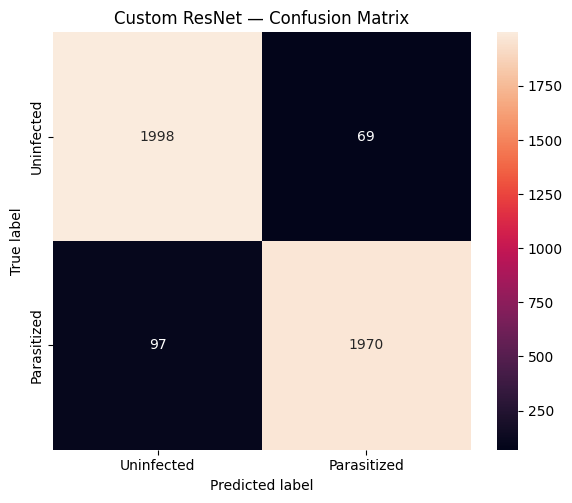

In [36]:
def plot_confusion_matrix(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        square=True,
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES,
    )
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.title("Custom ResNet — Confusion Matrix")
    plt.tight_layout()
    plt.show()
plot_confusion_matrix(y_test, y_test_prob)


## 22. Final ROC curve

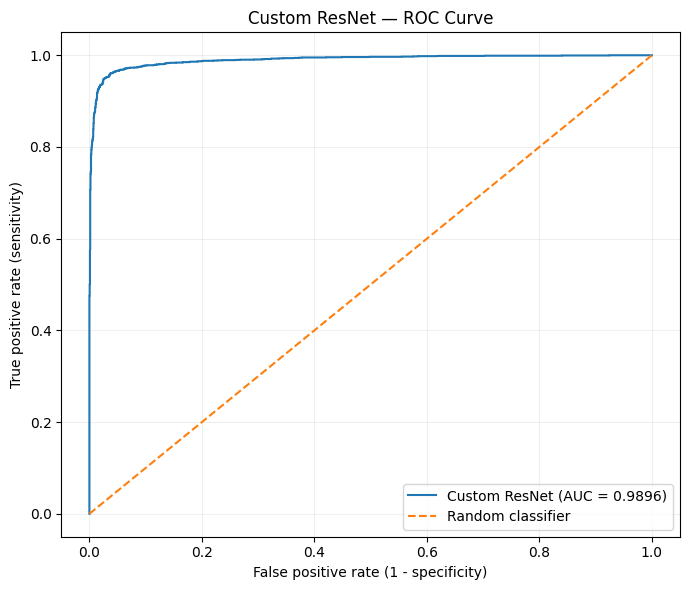

In [37]:
def plot_roc_curve(y_true, y_prob):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    auc_value = roc_auc_score(y_true, y_prob)
    plt.figure(figsize=(7, 6))
    plt.plot(fpr, tpr, label=f"Custom ResNet (AUC = {auc_value:.4f})")
    plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")
    plt.xlabel("False positive rate (1 - specificity)")
    plt.ylabel("True positive rate (sensitivity)")
    plt.title("Custom ResNet — ROC Curve")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()
plot_roc_curve(y_test, y_test_prob)


## 23. Classification report

In [38]:
def print_final_classification_report(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    print(
        classification_report(
            y_true,
            y_pred,
            target_names=CLASS_NAMES,
            digits=4,
            zero_division=0,
        )
    )
print_final_classification_report(y_test, y_test_prob)


              precision    recall  f1-score   support

  Uninfected     0.9537    0.9666    0.9601      2067
 Parasitized     0.9662    0.9531    0.9596      2067

    accuracy                         0.9598      4134
   macro avg     0.9599    0.9598    0.9598      4134
weighted avg     0.9599    0.9598    0.9598      4134



## 24. Inspect misclassified test images

This helper shows representative errors. It does not claim why the model made an error; the images are evidence for later error analysis.

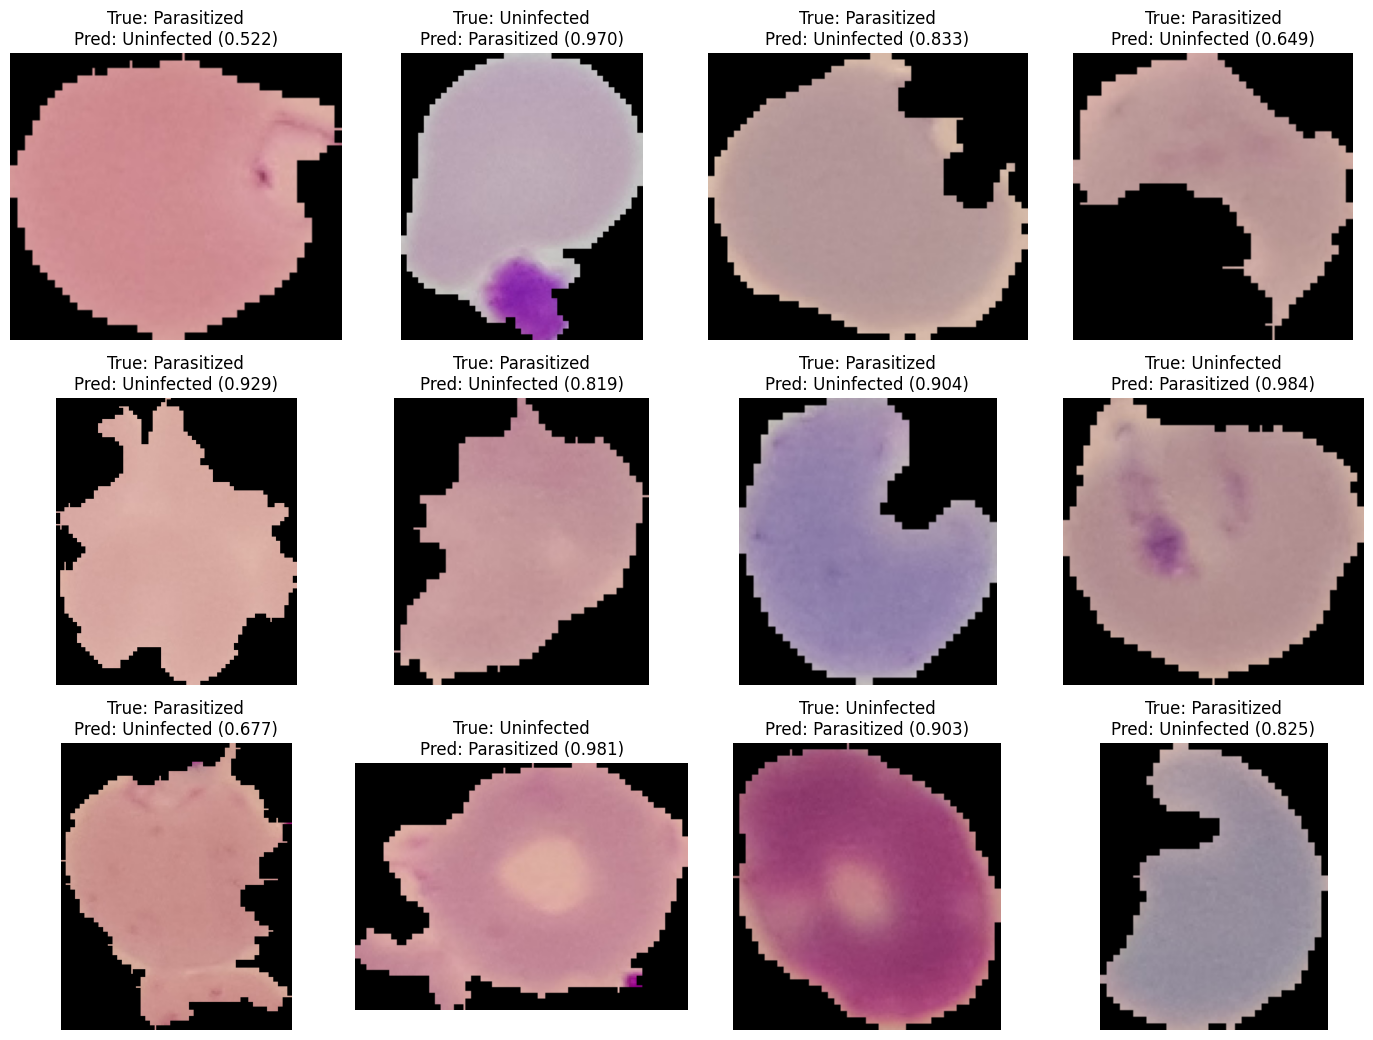

In [39]:
def show_misclassified_examples(model, frame, n=12, threshold=0.5, random_state=SEED):
    ds = make_dataset(frame, batch_size=32, shuffle=False)
    y_true, y_prob = collect_predictions(model, ds)
    y_pred = (y_prob >= threshold).astype(int)
    wrong = np.where(y_true != y_pred)[0]
    if len(wrong) == 0:
        print("No misclassified examples found.")
        return
    rng = np.random.default_rng(random_state)
    chosen = rng.choice(wrong, size=min(n, len(wrong)), replace=False)
    cols = 4
    rows = math.ceil(len(chosen) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(14, 3.5 * rows))
    axes = np.atleast_1d(axes).ravel()
    for ax, idx in zip(axes, chosen):
        path = frame.iloc[idx]["path"]
        image = plt.imread(path)
        true_name = CLASS_NAMES[y_true[idx]]
        pred_name = CLASS_NAMES[y_pred[idx]]
        confidence = y_prob[idx] if y_pred[idx] == 1 else 1 - y_prob[idx]
        ax.imshow(image)
        ax.set_title(
            f"True: {true_name}\nPred: {pred_name} ({confidence:.3f})"
        )
        ax.axis("off")
    for ax in axes[len(chosen):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()
show_misclassified_examples(final_model, test_df, n=12)


## 25. TensorBoard

TensorBoard logs are written to `/kaggle/working/logs/fit`. When experiments are trained across separate Kaggle sessions, combine the saved log directories locally before launching TensorBoard so all seven runs appear together.

In [60]:
%load_ext tensorboard
%tensorboard --logdir /kaggle/working/logs/fit


The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6006 (pid 1647), started 0:02:19 ago. (Use '!kill 1647' to kill it.)

<IPython.core.display.Javascript object>

In [63]:
shutil.make_archive(
    "/kaggle/working/tensorboard_logs",
    "zip",
    "/kaggle/working/logs"
)


'/kaggle/working/tensorboard_logs.zip'

## 26. Grad-CAM

Grad-CAM uses the final convolutional feature map exposed by the custom ResNet to visualize image regions that contribute to the prediction.

In [42]:
def make_gradcam_heatmap(model, image_tensor):
    image_tensor = tf.cast(image_tensor, tf.float32)

    with tf.GradientTape() as tape:
        probability = model(image_tensor, training=False)
        target = probability[:, 0]

    feature_maps = model.last_conv_output
    gradients = tape.gradient(target, feature_maps)

    weights = tf.reduce_mean(gradients, axis=(1, 2), keepdims=True)
    heatmap = tf.reduce_sum(weights * feature_maps, axis=-1)
    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / (tf.reduce_max(heatmap, axis=(1, 2), keepdims=True) + 1e-8)

    return heatmap[0].numpy(), float(probability[0, 0].numpy())


def show_gradcam_examples(model, frame, n=4, random_state=SEED):
    sample = frame.sample(n=min(n, len(frame)), random_state=random_state).reset_index(drop=True)
    cols = 2
    rows = math.ceil(len(sample) / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(12, 5 * rows))
    axes = np.atleast_1d(axes).ravel()

    for ax, (_, row) in zip(axes, sample.iterrows()):
        image = tf.io.read_file(row["path"])
        image = tf.image.decode_image(image, channels=3, expand_animations=False)
        image = tf.image.resize(image, IMG_SIZE)
        image = tf.cast(image, tf.float32) / 255.0

        heatmap, probability = make_gradcam_heatmap(
            model,
            tf.expand_dims(image, axis=0),
        )

        original = image.numpy()
        ax.imshow(original)
        ax.imshow(
            heatmap,
            cmap="jet",
            alpha=0.4,
            extent=(0, IMG_SIZE[1], IMG_SIZE[0], 0),
        )

        predicted = int(probability >= 0.5)
        true_name = CLASS_NAMES[int(row["label"])]
        predicted_name = CLASS_NAMES[predicted]

        ax.set_title(
            f"True: {true_name} | Predicted: {predicted_name} | Score: {probability:.3f}"
        )
        ax.axis("off")

    for ax in axes[len(sample):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


show_gradcam_examples(final_model, test_df, n=4)


Prediction shape: (1, 1)
Final convolutional feature map shape: (1, 28, 28, 512)
Grad-CAM feature map is accessible: True


## 27. Save the final model artifacts

The final configuration, held-out test metrics, and selected model weights are saved under `/kaggle/working/artifacts`.

In [44]:
def save_final_artifacts(selected_config, test_metrics):
    with open(ARTIFACT_ROOT / "final_custom_resnet_config.json", "w") as f:
        json.dump(selected_config, f, indent=2)

    serializable_metrics = {
        key: float(value) if isinstance(value, (np.floating, float)) else int(value)
        for key, value in test_metrics.items()
    }

    with open(ARTIFACT_ROOT / "final_custom_resnet_test_metrics.json", "w") as f:
        json.dump(serializable_metrics, f, indent=2)

    checkpoint_path = CHECKPOINT_ROOT / f"{selected_config['name']}.weights.h5"
    final_weights_path = ARTIFACT_ROOT / "final_custom_resnet.weights.h5"

    if checkpoint_path.exists():
        shutil.copy2(checkpoint_path, final_weights_path)

    print("Saved final artifacts to", ARTIFACT_ROOT)


save_final_artifacts(selected_config, test_metrics)


Saved configuration and test metrics to /kaggle/working/artifacts


# Part A — submission checklist

- [x] Stratified train/validation/test split
- [x] Custom ResNet implemented with Keras subclassing
- [x] Model trained from scratch
- [x] Seven meaningful experiments completed
- [x] TensorBoard logging configured
- [x] Validation metrics recorded for each experiment
- [x] Final experiment selected using validation data
- [x] Held-out test evaluation completed
- [x] Accuracy and loss curves generated
- [x] Confusion matrix generated
- [x] ROC/AUC analysis generated
- [x] Misclassified examples inspected
- [x] Grad-CAM visualization included
- [x] Final configuration, metrics, and weights saved
